# **🛠️ BaristaBot: A Conversational Cafe Ordering System with LangGraph**

This notebook defines a stateful graph-based application built on top of the Gemini API using LangGraph.
It simulates a real-world cafe assistant that can:
* Use natural language to take coffee/tea orders.
* Offer a real-time menu using a tool.
* Confirm and modify orders.
* Loop through conversation until an order is placed.
* Handle tool calls using LangGraph’s ToolNode mechanism.

### **1. Install Dependencies**
We install the LangGraph SDK and LangChain support for the Gemini API.

In [1]:
%pip install -qU "langgraph==1.1.5" "langchain-google-genai==4.1.2" "google-genai==1.66.0"

### **2. Set up your API key**
To run the following cell, your API key must be stored in a Kaggle secret named `GOOGLE_API_KEY` (Add-ons -> Secrets).

In [2]:
import os
from google.colab import userdata

try:
    # Récupération propre de la clé via les secrets natifs de Colab
    GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
    print("Clé API Gemini configurée avec succès sur Colab !")
except Exception as e:
    print("Erreur : Assure-toi d'avoir ajouté 'GOOGLE_API_KEY' dans l'onglet Secrets (icône clé 🔑) et d'avoir activé l'accès.")

Clé API Gemini configurée avec succès sur Colab !


### **3. Define State Schema and Instructions**
We establish `OrderState` to preserve the chat history, current structured order, and the workflow completion flag.

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class OrderState(TypedDict):
    """State representing the customer's order conversation."""
    messages: Annotated[list, add_messages]
    order: list[str]
    finished: bool

BARISTABOT_SYSINT = (
    "system",
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

### **4. Define basic Chatbot Node**
A simple single-turn wrapper node around the initialized Gemini LLM instance.

In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}

graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

chat_graph = graph_builder.compile()

### **5. Visualize the simple Graph**

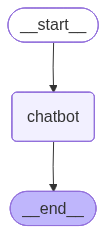

In [5]:
from IPython.display import Image, display
try:
    display(Image(chat_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(chat_graph.get_graph().draw_mermaid())

### **6 & 7. Single-turn Invocation tests**

In [6]:
from langchain_core.messages import HumanMessage

user_msg = HumanMessage(content="Hi, what kind of cafe is this?")
state = chat_graph.invoke({"messages": [user_msg]})

for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")

HumanMessage: Hi, what kind of cafe is this?
AIMessage: Welcome! We are a cafe focused on delicious coffee and teas. What can I get for you today? Would you like to hear about our menu?


### **8 & 9. Add Human Node and Loop Exit Logic**
Instead of running a continuous Python while loop outside, we build a cycling state interaction loop right inside the graph framework.

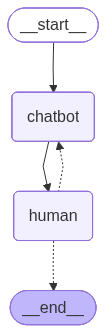

In [7]:
from typing import Literal
from langchain_core.messages.ai import AIMessage

def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    last_msg = state["messages"][-1]
    print("Model:", last_msg.content)

    user_input = input("User: ")
    if user_input.lower() in {"q", "quit", "exit", "goodbye"}:
        state["finished"] = True
    return state | {"messages": [("user", user_input)]}

def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """The chatbot with a fallback initial greeting clause."""
    if state["messages"]:
        new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)
    return state | {"messages": [new_output]}

def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    """Route back to the chatbot unless exit criteria flags are raised."""
    if state.get("finished", False):
        return END
    return "chatbot"

graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", "human")
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

chat_with_human_graph = graph_builder.compile()
try:
    display(Image(chat_with_human_graph.get_graph().draw_mermaid_png()))
except:
    pass

### **10. Add a Dynamic Live Menu Tool**

In [8]:
from langchain_core.tools import tool

@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    return """
    MENU:
    Coffee Drinks:
    Espresso | Americano | Cold Brew
    Coffee Drinks with Milk:
    Latte | Cappuccino | Cortado | Macchiato | Mocha | Flat White
    Tea Drinks:
    English Breakfast Tea | Green Tea | Earl Grey
    Tea Drinks with Milk:
    Chai Latte | Matcha Latte | London Fog
    Other Drinks:
    Steamer | Hot Chocolate
    Modifiers:
    Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free; Default option: whole
    Espresso shots: Single, Double, Triple, Quadruple; default: Double
    Caffeine: Decaf, Regular; default: Regular
    Hot-Iced: Hot, Iced; Default: Hot
    Sweeteners: vanilla sweetener, hazelnut sweetener, caramel sauce, chocolate sauce
    """

### **11. Handle Orders and Setup Ordering Stateful Actions**
We declare functional declarations to share schemas with the LLM layer, then intercept tool outputs inside an isolated node state processor.

In [9]:
from collections.abc import Iterable
from random import randint
from langchain_core.messages.tool import ToolMessage

@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Adds the specified drink to the customer's order, including any modifiers."""
    pass

@tool
def confirm_order() -> str:
    """Asks the customer if the order is correct."""
    pass

@tool
def get_order() -> str:
    """Returns the users order so far. One item per line."""
    pass

@tool
def clear_order():
    """Removes all items from the user's order."""
    pass

@tool
def place_order() -> int:
    """Sends the order to the barista for fulfillment."""
    pass

def order_node(state: OrderState) -> OrderState:
    """The ordering node intercepting execution context loops to adjust application states."""
    tool_msg = state["messages"][-1]
    order = state.get("order", [])
    if order is None: order = []

    outbound_msgs = []
    order_placed = False

    for tool_call in tool_msg.tool_calls:
        response = ""
        t_name = tool_call["name"]

        if t_name == "add_to_order":
            drink = tool_call["args"].get("drink", "Unknown Drink")
            modifiers = tool_call["args"].get("modifiers", [])
            modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"
            order.append(f"{drink} ({modifier_str})")
            response = "Added to order. Total items:\n" + "\n".join(order)

        elif t_name == "confirm_order":
            print("\nYour order:")
            if not order:
                print("  (no items)")
            for drink in order:
                print(f"  {drink}")
            response = input("Is this correct? ")

        elif t_name == "get_order":
            response = "\n".join(order) if order else "(no order)"

        elif t_name == "clear_order":
            order.clear()
            response = "Order cleared."

        elif t_name == "place_order":
            print("\nSending order to kitchen!")
            print("\n".join(order))
            order_placed = True
            response = str(randint(1, 5))
        else:
            raise NotImplementedError(f'Unknown tool: {t_name}')

        outbound_msgs.append(
            ToolMessage(content=str(response), name=t_name, tool_call_id=tool_call["id"])
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}

### **12. Define Conditional Routing Rules and Compile Graph**

In [10]:
from langgraph.prebuilt import ToolNode

auto_tools = [get_menu]
tool_node = ToolNode(auto_tools)
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]
all_tools = auto_tools + order_tools
llm_with_tools = llm.bind_tools(all_tools)

def maybe_route_to_tools(state: OrderState) -> Literal["tools", "ordering", "human", "__end__"]:
    if not (msgs := state.get("messages", [])): return "human"
    msg = msgs[-1]
    if state.get("finished", False): return END
    if hasattr(msg, "tool_calls") and len(msg.tool_calls) > 0:
        if any(tool["name"] == "get_menu" for tool in msg.tool_calls):
            return "tools"
        return "ordering"
    return "human"

def chatbot_with_tools(state: OrderState) -> OrderState:
    defaults = {"order": [], "finished": False}
    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)
    return defaults | state | {"messages": [new_output]}

builder = StateGraph(OrderState)
builder.add_node("chatbot", chatbot_with_tools)
builder.add_node("human", human_node)
builder.add_node("tools", tool_node)
builder.add_node("ordering", order_node)

builder.add_conditional_edges("chatbot", maybe_route_to_tools)
builder.add_conditional_edges("human", maybe_exit_human_node)
builder.add_edge("tools", "chatbot")
builder.add_edge("ordering", "chatbot")
builder.add_edge(START, "chatbot")

graph_with_order_tools = builder.compile()

### **13. Run the complete Ordering Agent System**
Execute the block below to talk with your BaristaBot via terminal input streams.

In [ ]:
from pprint import pprint

config = {"recursion_limit": 100}
print("Starting system loop... (Type 'q' to quit)\n")
final_state = graph_with_order_tools.invoke({"messages": [], "order": [], "finished": False}, config)

print("\n--- Final State History Summary ---")
pprint(final_state)

Starting system loop... (Type 'q' to quit)

Model: Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?
User: can i have a capucino ?
Model: [{'type': 'text', 'text': 'Yes, we have cappuccino on the menu. Would you like to add it to your order?', 'extras': {'signature': 'CsABAQw51sd+Bg53T5zMoBggJdIwkc6CFgi3xHs0s2Il62tcsg+piqftSnFXJTMcm6EdppA2Tf5MAJpRJNZpaOlnuzeeVJyveBqMedWlkcDUKPWcla+BMbJ+weeH+f9kPVUfaPPyF7SKwZR0yDb7TM4eghwPlDheHhP9qWQOQlVDiXb3Qzt8SDmVpx6MMcvDuHEu39itBCMxw2EotMzXuXRRBqU9im7L5mbZP/aoi5Ek0uEMZ7dBUBqnWOnR7gbdDwux'}}]
